# CWE 32k — Entropy Analysis: Baseline vs Controller

**Runs:**
- Baseline: `baseline_no_session_prefixON_32k_cwefwe` — `calibrated_scalar`, `session_size=100k`, `temp_gain=0.0`
- Controller: `50session_3cali_prefixON_0p7ema_32k_cwe_maxtemp1` — `calibrated_per_head`, `session_size=50`, `temp_gain=0.15`, `target_trim_ratio=0.1`

**Metric:** `ruler_all_acc` = mean(`_ruler_all_hit`) × 100, where `_ruler_all_hit` = fraction of 10 target words found.

**Note on normalization:** The logged `entropy_mean` is raw Shannon entropy in nats. The controller internally uses normalized entropy `H_norm = entropy_mean / log(kv_len)` (∈ [0,1]), which is also the scale of `prompt_target_mean`. Analysis 2 uses the recalculated `H_norm` so comparisons are apples-to-apples.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

ROOT = Path("/c2/jenny/r3/RULER_outputs/llama3.1-8b-chat/synthetic/32768/data_session_runs/cwe")
BASE_TAG = "baseline_no_session_prefixON_32k_cwefwe"
CTRL_TAG = "50session_3cali_prefixON_0p7ema_32k_cwe_maxtemp1"

def load_jsonl(path):
    with open(path) as f:
        return [json.loads(l) for l in f if l.strip()]

base_preds = load_jsonl(ROOT / f"cwe_entropy_attn_predictions_{BASE_TAG}")
ctrl_preds = load_jsonl(ROOT / f"cwe_entropy_attn_predictions_{CTRL_TAG}")
base_elog  = load_jsonl(ROOT / f"cwe_entropy_attn_entropy_log_{BASE_TAG}")
ctrl_elog  = load_jsonl(ROOT / f"cwe_entropy_attn_entropy_log_{CTRL_TAG}")

def max_steps(elog):
    return max(s["step"] for ex in elog for s in ex["entropy_log"]) + 1

N_STEPS = min(max_steps(base_elog), max_steps(ctrl_elog))
steps = np.arange(N_STEPS)
print(f"Comparing first {N_STEPS} steps")

def to_arrays(elog, n_steps):
    """
    Returns:
      H     (N, T) raw entropy in nats
      H_norm(N, T) normalized: H / log(kv_len)  — the quantity the controller uses
      Std   (N, T) raw entropy_std
      T_arr (N, T) temp_mean
      tgt   (N,)   prompt_target_mean (already normalized, from prefill)
    """
    N = len(elog)
    H      = np.full((N, n_steps), np.nan, dtype=np.float32)
    H_norm = np.full((N, n_steps), np.nan, dtype=np.float32)
    Std    = np.full((N, n_steps), np.nan, dtype=np.float32)
    T_arr  = np.full((N, n_steps), np.nan, dtype=np.float32)
    tgt    = np.zeros(N, dtype=np.float32)
    for i, ex in enumerate(elog):
        tgt[i] = ex["prompt_target_mean"]
        for s in ex["entropy_log"]:
            st = s["step"]
            if st >= n_steps:
                continue
            H[i, st]      = s["entropy_mean"]
            kv             = max(s["kv_len"], 2)           # guard log(0)
            H_norm[i, st]  = s["entropy_mean"] / np.log(kv)
            Std[i, st]     = s["entropy_std"]
            T_arr[i, st]   = s["temp_mean"]
    return H, H_norm, Std, T_arr, tgt

base_H, base_Hn, base_S, base_T, base_tgt = to_arrays(base_elog, N_STEPS)
ctrl_H, ctrl_Hn, ctrl_S, ctrl_T, ctrl_tgt = to_arrays(ctrl_elog, N_STEPS)

# ruler_all_hit: fraction of 10 target words found (primary CWE metric)
base_score = np.array([p["_ruler_all_hit"] for p in base_preds], dtype=np.float32)
ctrl_score = np.array([p["_ruler_all_hit"] for p in ctrl_preds], dtype=np.float32)
base_hit   = base_score > 0
ctrl_hit   = ctrl_score > 0

ctrl_only = ctrl_hit & ~base_hit
both_hit  = ctrl_hit &  base_hit
both_miss = ~ctrl_hit & ~base_hit
base_only = base_hit & ~ctrl_hit

print(f"Baseline  ruler_all_acc: {base_score.mean()*100:.2f}%  (hit: {base_hit.sum()}/500)")
print(f"Controller ruler_all_acc: {ctrl_score.mean()*100:.2f}%  (hit: {ctrl_hit.sum()}/500)")
print(f"\nctrl-only: {ctrl_only.sum()}  both hit: {both_hit.sum()}  both miss: {both_miss.sum()}  base-only: {base_only.sum()}")
print(f"\nH_norm range — baseline:   [{np.nanmin(base_Hn):.3f}, {np.nanmax(base_Hn):.3f}]  mean={np.nanmean(base_Hn):.3f}")
print(f"H_norm range — controller: [{np.nanmin(ctrl_Hn):.3f}, {np.nanmax(ctrl_Hn):.3f}]  mean={np.nanmean(ctrl_Hn):.3f}")
print(f"Target range — baseline:   [{base_tgt.min():.3f}, {base_tgt.max():.3f}]  mean={base_tgt.mean():.3f}")
print(f"Target range — controller: [{ctrl_tgt.min():.3f}, {ctrl_tgt.max():.3f}]  mean={ctrl_tgt.mean():.3f}")

Comparing first 48 steps


Baseline  ruler_all_acc: 0.70%  (hit: 15/500)
Controller ruler_all_acc: 27.14%  (hit: 327/500)

ctrl-only: 312  both hit: 15  both miss: 173  base-only: 0

H_norm range — baseline:   [0.241, 0.464]  mean=0.331
H_norm range — controller: [0.201, 0.459]  mean=0.309
Target range — baseline:   [0.330, 0.330]  mean=0.330
Target range — controller: [0.326, 0.328]  mean=0.327


## Score distribution (`_ruler_all_hit`)

`ruler_all_acc` = mean score × 100. Scores are in {0, 0.1, ..., 0.9} — no example achieves all 10 words.

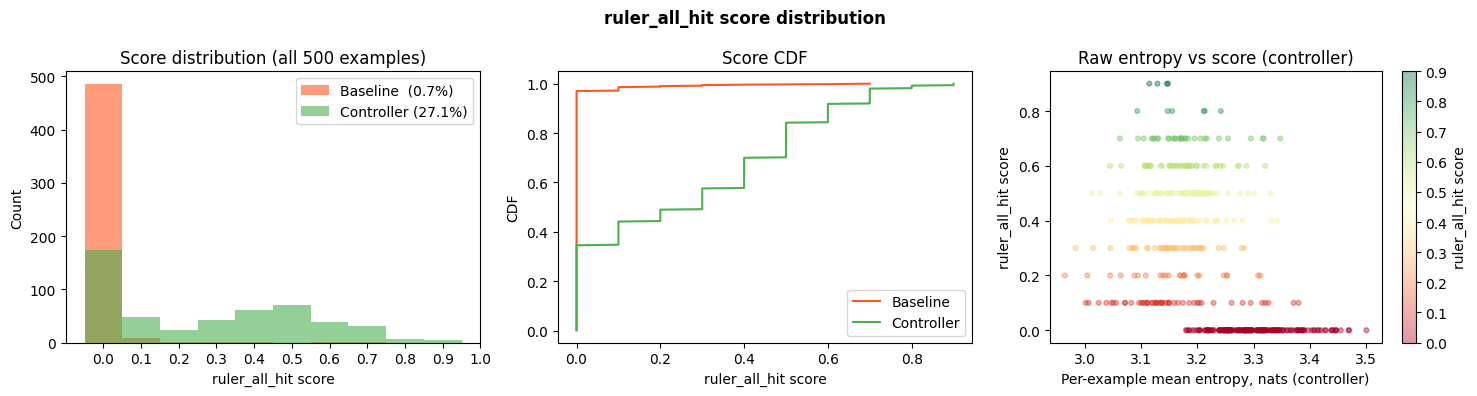

In [2]:
C = dict(base_hit="#2196F3", base_miss="#FF5722", ctrl_hit="#4CAF50", ctrl_miss="#F44336")
BAND = 0.18

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("ruler_all_hit score distribution", fontsize=12, fontweight="bold")

score_bins = np.arange(-0.05, 1.05, 0.1)
ax = axes[0]
ax.hist(base_score, bins=score_bins, alpha=0.6, color="#FF5722",
        label=f"Baseline  ({base_score.mean()*100:.1f}%)")
ax.hist(ctrl_score, bins=score_bins, alpha=0.6, color="#4CAF50",
        label=f"Controller ({ctrl_score.mean()*100:.1f}%)")
ax.set_xticks(np.arange(0, 1.1, 0.1))
ax.set_xlabel("ruler_all_hit score")
ax.set_ylabel("Count")
ax.set_title("Score distribution (all 500 examples)")
ax.legend()

ax = axes[1]
for scores, lbl, col in [(base_score, "Baseline", "#FF5722"), (ctrl_score, "Controller", "#4CAF50")]:
    s = np.sort(scores)
    ax.plot(s, np.arange(1, len(s)+1)/len(s), color=col, label=lbl)
ax.set_xlabel("ruler_all_hit score")
ax.set_ylabel("CDF")
ax.set_title("Score CDF")
ax.legend()

ax = axes[2]
ctrl_H_mean = np.nanmean(ctrl_H, axis=1)
sc = ax.scatter(ctrl_H_mean, ctrl_score, c=ctrl_score, cmap="RdYlGn",
                alpha=0.4, s=12, vmin=0, vmax=0.9)
plt.colorbar(sc, ax=ax, label="ruler_all_hit score")
ax.set_xlabel("Per-example mean entropy, nats (controller)")
ax.set_ylabel("ruler_all_hit score")
ax.set_title("Raw entropy vs score (controller)")

fig.tight_layout()
plt.show()

## Analysis 1 — Entropy distribution: success vs fail

Uses **raw nats** (left two columns) and **normalized H_norm** (right column) for comparison.

/tmp/ipykernel_2179293/2737064968.py:25: RuntimeWarning: Mean of empty slice
  m = np.nanmean(H[mask], axis=0)
/c2/jenny/miniconda3/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_2179293/2737064968.py:37: RuntimeWarning: Mean of empty slice
  m = np.nanmean(Hn[mask], axis=0)


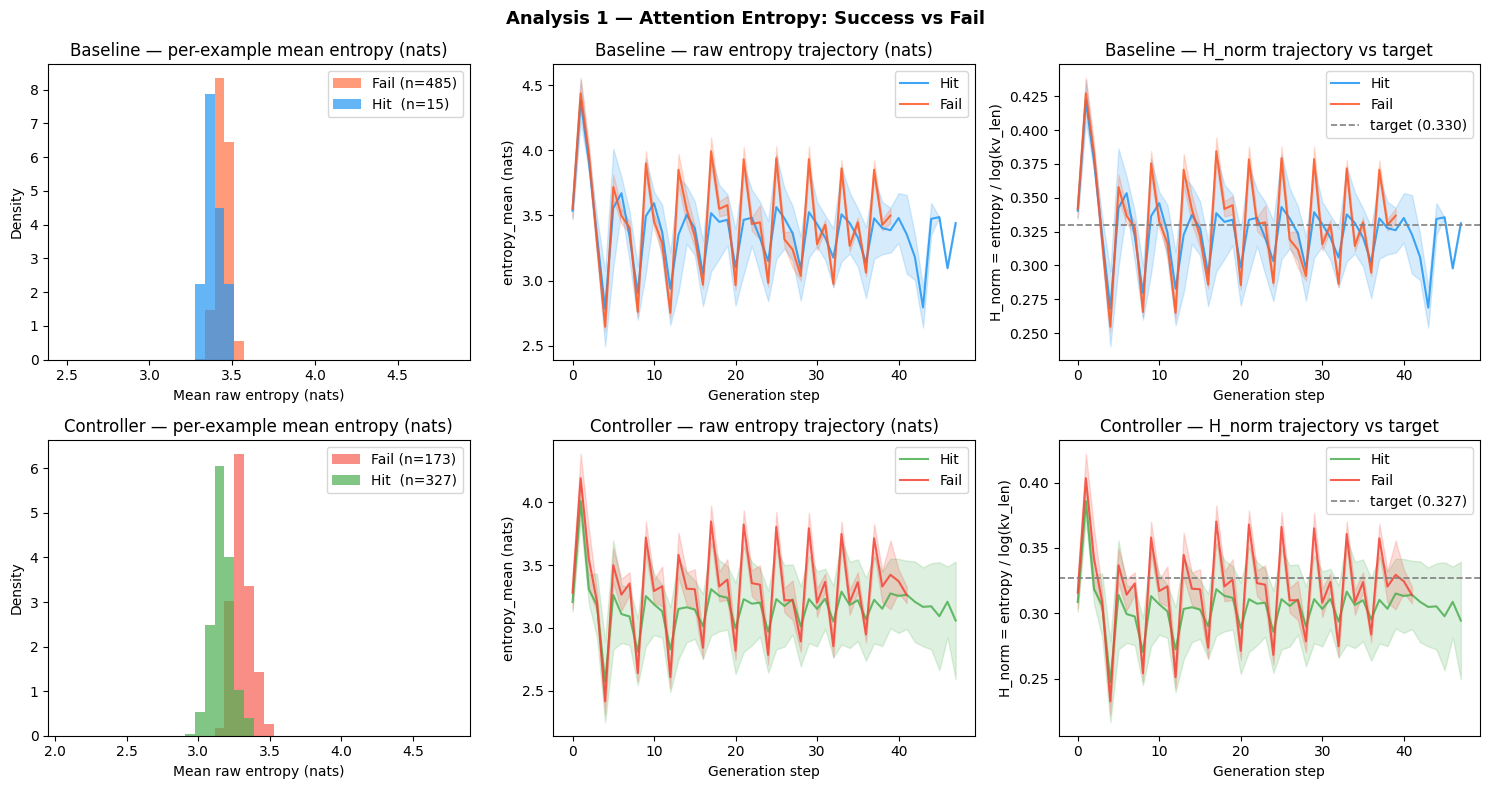

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Analysis 1 — Attention Entropy: Success vs Fail", fontsize=13, fontweight="bold")

rows = [
    ("Baseline",   base_H, base_Hn, base_S, base_tgt, base_hit, C["base_hit"], C["base_miss"]),
    ("Controller", ctrl_H, ctrl_Hn, ctrl_S, ctrl_tgt, ctrl_hit, C["ctrl_hit"], C["ctrl_miss"]),
]

for row_i, (label, H, Hn, Std, tgt, hit, c_hit, c_miss) in enumerate(rows):
    n_hit, n_miss = hit.sum(), (~hit).sum()

    # col 0: per-example mean raw entropy histogram
    ax = axes[row_i, 0]
    bins = np.linspace(np.nanmin(H), np.nanmax(H), 40)
    ax.hist(np.nanmean(H[~hit], axis=1), bins=bins, alpha=0.6, color=c_miss, density=True, label=f"Fail (n={n_miss})")
    ax.hist(np.nanmean(H[hit],  axis=1), bins=bins, alpha=0.7, color=c_hit,  density=True, label=f"Hit  (n={n_hit})")
    ax.set_title(f"{label} — per-example mean entropy (nats)")
    ax.set_xlabel("Mean raw entropy (nats)")
    ax.set_ylabel("Density")
    ax.legend()

    # col 1: raw entropy trajectory
    ax = axes[row_i, 1]
    for mask, lbl, col in [(hit, "Hit", c_hit), (~hit, "Fail", c_miss)]:
        m = np.nanmean(H[mask], axis=0)
        s = np.nanstd(H[mask],  axis=0)
        ax.plot(steps, m, color=col, label=lbl, alpha=0.85)
        ax.fill_between(steps, m-s, m+s, color=col, alpha=BAND)
    ax.set_title(f"{label} — raw entropy trajectory (nats)")
    ax.set_xlabel("Generation step")
    ax.set_ylabel("entropy_mean (nats)")
    ax.legend()

    # col 2: normalized entropy trajectory vs target (apples-to-apples)
    ax = axes[row_i, 2]
    for mask, lbl, col in [(hit, "Hit", c_hit), (~hit, "Fail", c_miss)]:
        m = np.nanmean(Hn[mask], axis=0)
        s = np.nanstd(Hn[mask],  axis=0)
        ax.plot(steps, m, color=col, label=lbl, alpha=0.85)
        ax.fill_between(steps, m-s, m+s, color=col, alpha=BAND)
    ax.axhline(tgt.mean(), color="gray", ls="--", lw=1.2, label=f"target ({tgt.mean():.3f})")
    ax.set_title(f"{label} — H_norm trajectory vs target")
    ax.set_xlabel("Generation step")
    ax.set_ylabel("H_norm = entropy / log(kv_len)")
    ax.legend()

fig.tight_layout()
plt.show()

## Analysis 1b — Entropy distribution by `ruler_all_acc` score group

Binary hit/miss conflates partial and good retrievals. Here examples are split by `_ruler_all_hit` score into three groups that directly reflect `ruler_all_acc`:
- **miss**: score = 0 (no words retrieved)
- **partial**: 0 < score < 0.5 (1–4 words)
- **good**: score ≥ 0.5 (5–9 words)

Baseline: miss=485  partial=13  good=2
Controller: miss=173  partial=177  good=150


/tmp/ipykernel_2179293/3426153859.py:49: RuntimeWarning: Mean of empty slice
  m = np.nanmean(H[mask], axis=0)
/tmp/ipykernel_2179293/3426153859.py:62: RuntimeWarning: Mean of empty slice
  m = np.nanmean(Hn[mask], axis=0)


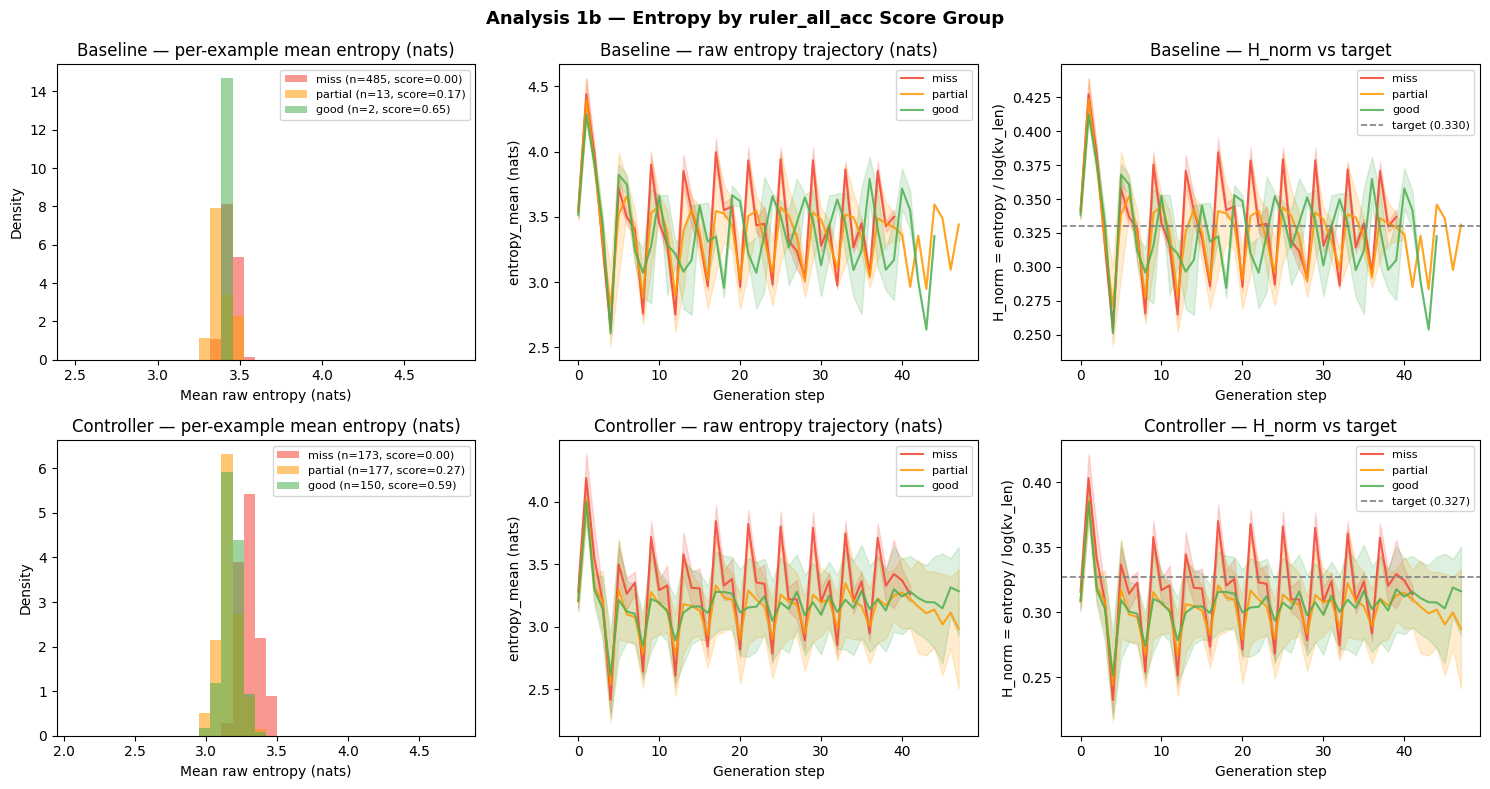


Mean raw entropy and H_norm by score group:
                           raw_H   H_norm      tgt      err
  Baseline     miss         3.4457   0.3316   0.3299  +0.0017
  Baseline     partial      3.3914   0.3264   0.3299  -0.0035
  Baseline     good         3.3952   0.3268   0.3299  -0.0031
  Controller   miss         3.3041   0.3180   0.3268  -0.0088
  Controller   partial      3.1563   0.3038   0.3268  -0.0231
  Controller   good         3.1768   0.3057   0.3268  -0.0211


In [4]:
# Score-based groups for ruler_all_acc analysis
def score_groups(score):
    miss    = score == 0
    partial = (score > 0) & (score < 0.5)
    good    = score >= 0.5
    return miss, partial, good

base_miss_g, base_partial_g, base_good_g = score_groups(base_score)
ctrl_miss_g, ctrl_partial_g, ctrl_good_g = score_groups(ctrl_score)

for name, miss, partial, good in [("Baseline",   base_miss_g, base_partial_g, base_good_g),
                                    ("Controller", ctrl_miss_g, ctrl_partial_g, ctrl_good_g)]:
    print(f"{name}: miss={miss.sum()}  partial={partial.sum()}  good={good.sum()}")

SG = {"miss": "#F44336", "partial": "#FF9800", "good": "#4CAF50"}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Analysis 1b — Entropy by ruler_all_acc Score Group", fontsize=13, fontweight="bold")

rows = [
    ("Baseline",   base_H, base_Hn, base_tgt,
     base_miss_g, base_partial_g, base_good_g, base_score),
    ("Controller", ctrl_H, ctrl_Hn, ctrl_tgt,
     ctrl_miss_g, ctrl_partial_g, ctrl_good_g, ctrl_score),
]

for row_i, (label, H, Hn, tgt, miss, partial, good, score) in enumerate(rows):
    sg = [(miss,    "miss",    SG["miss"]),
          (partial, "partial", SG["partial"]),
          (good,    "good",    SG["good"])]

    # col 0: per-example mean raw entropy histogram
    ax = axes[row_i, 0]
    bins = np.linspace(np.nanmin(H), np.nanmax(H), 35)
    for mask, lbl, col in sg:
        if not mask.sum(): continue
        mean_score = score[mask].mean()
        ax.hist(np.nanmean(H[mask], axis=1), bins=bins, alpha=0.55, color=col,
                density=True, label=f"{lbl} (n={mask.sum()}, score={mean_score:.2f})")
    ax.set_title(f"{label} — per-example mean entropy (nats)")
    ax.set_xlabel("Mean raw entropy (nats)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

    # col 1: raw entropy trajectory
    ax = axes[row_i, 1]
    for mask, lbl, col in sg:
        if not mask.sum(): continue
        m = np.nanmean(H[mask], axis=0)
        s = np.nanstd(H[mask],  axis=0)
        ax.plot(steps, m, color=col, label=lbl, alpha=0.85)
        ax.fill_between(steps, m-s, m+s, color=col, alpha=BAND)
    ax.set_title(f"{label} — raw entropy trajectory (nats)")
    ax.set_xlabel("Generation step")
    ax.set_ylabel("entropy_mean (nats)")
    ax.legend(fontsize=8)

    # col 2: H_norm trajectory vs target
    ax = axes[row_i, 2]
    for mask, lbl, col in sg:
        if not mask.sum(): continue
        m = np.nanmean(Hn[mask], axis=0)
        s = np.nanstd(Hn[mask],  axis=0)
        ax.plot(steps, m, color=col, label=lbl, alpha=0.85)
        ax.fill_between(steps, m-s, m+s, color=col, alpha=BAND)
    ax.axhline(tgt.mean(), color="gray", ls="--", lw=1.2, label=f"target ({tgt.mean():.3f})")
    ax.set_title(f"{label} — H_norm vs target")
    ax.set_xlabel("Generation step")
    ax.set_ylabel("H_norm = entropy / log(kv_len)")
    ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

# Mean entropy per score group
print("\nMean raw entropy and H_norm by score group:")
print(f"{'':12} {'':10} {'raw_H':>8} {'H_norm':>8} {'tgt':>8} {'err':>8}")
for label, H, Hn, tgt, miss, partial, good in [
    ("Baseline",   base_H, base_Hn, base_tgt, base_miss_g, base_partial_g, base_good_g),
    ("Controller", ctrl_H, ctrl_Hn, ctrl_tgt, ctrl_miss_g, ctrl_partial_g, ctrl_good_g),
]:
    for mask, lbl in [(miss, "miss"), (partial, "partial"), (good, "good")]:
        if not mask.sum(): continue
        raw = np.nanmean(H[mask])
        hn  = np.nanmean(Hn[mask])
        err = hn - tgt.mean()
        print(f"  {label:<12} {lbl:<10} {raw:>8.4f} {hn:>8.4f} {tgt.mean():>8.4f} {err:>+8.4f}")

## Analysis 2 — Tracking error in normalized space

`err = H_norm − target` where both are in [0, 1]. This is exactly the error signal the controller computes. The previous version used raw nats minus a normalized target, which was meaningless.

/tmp/ipykernel_2179293/2245724864.py:33: RuntimeWarning: Mean of empty slice
  m = np.nanmean(err[mask], axis=0)
/tmp/ipykernel_2179293/2245724864.py:46: RuntimeWarning: Mean of empty slice
  m = np.nanmean(np.abs(err[mask]), axis=0)


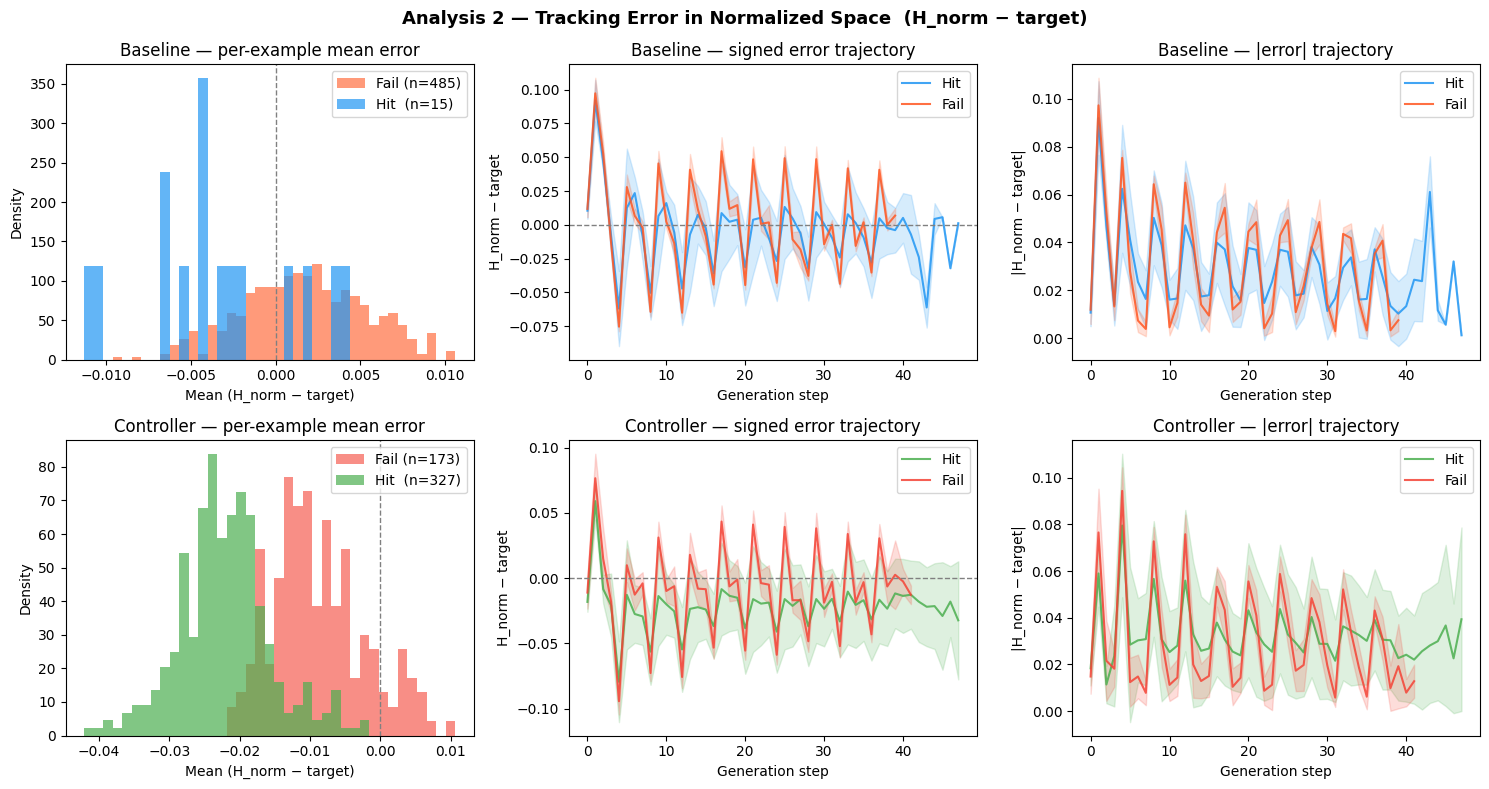

Normalized tracking error  (H_norm − target):
  Baseline   hit:  -0.0034   miss: +0.0017
  Controller hit:  -0.0221   miss: -0.0088

Mean |error|:
  Baseline:   0.0300
  Controller: 0.0319

Mean H_norm (all steps):
  Baseline:   0.3315   target: 0.3299
  Controller: 0.3092   target: 0.3268


In [5]:
base_err  = base_Hn - base_tgt[:, None]   # (N, T), normalized units
ctrl_err  = ctrl_Hn - ctrl_tgt[:, None]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Analysis 2 — Tracking Error in Normalized Space  (H_norm − target)",
             fontsize=13, fontweight="bold")

rows = [
    ("Baseline",   base_err, base_Hn, base_tgt, base_hit, C["base_hit"],  C["base_miss"]),
    ("Controller", ctrl_err, ctrl_Hn, ctrl_tgt, ctrl_hit, C["ctrl_hit"],  C["ctrl_miss"]),
]

for row_i, (label, err, Hn, tgt, hit, c_hit, c_miss) in enumerate(rows):
    n_hit, n_miss = hit.sum(), (~hit).sum()

    # col 0: histogram of per-example mean tracking error
    ax = axes[row_i, 0]
    h_err  = np.nanmean(err[hit],  axis=1)
    m_err  = np.nanmean(err[~hit], axis=1)
    all_e  = np.concatenate([h_err, m_err])
    bins   = np.linspace(all_e.min(), all_e.max(), 40)
    ax.hist(m_err, bins=bins, alpha=0.6, color=c_miss, density=True, label=f"Fail (n={n_miss})")
    ax.hist(h_err, bins=bins, alpha=0.7, color=c_hit,  density=True, label=f"Hit  (n={n_hit})")
    ax.axvline(0, color="gray", ls="--", lw=1)
    ax.set_title(f"{label} — per-example mean error")
    ax.set_xlabel("Mean (H_norm − target)")
    ax.set_ylabel("Density")
    ax.legend()

    # col 1: signed error trajectory
    ax = axes[row_i, 1]
    for mask, lbl, col in [(hit, "Hit", c_hit), (~hit, "Fail", c_miss)]:
        m = np.nanmean(err[mask], axis=0)
        s = np.nanstd(err[mask],  axis=0)
        ax.plot(steps, m, color=col, label=lbl, alpha=0.85)
        ax.fill_between(steps, m-s, m+s, color=col, alpha=BAND)
    ax.axhline(0, color="gray", ls="--", lw=1)
    ax.set_title(f"{label} — signed error trajectory")
    ax.set_xlabel("Generation step")
    ax.set_ylabel("H_norm − target")
    ax.legend()

    # col 2: |error| trajectory
    ax = axes[row_i, 2]
    for mask, lbl, col in [(hit, "Hit", c_hit), (~hit, "Fail", c_miss)]:
        m = np.nanmean(np.abs(err[mask]), axis=0)
        s = np.nanstd(np.abs(err[mask]),  axis=0)
        ax.plot(steps, m, color=col, label=lbl, alpha=0.85)
        ax.fill_between(steps, m-s, m+s, color=col, alpha=BAND)
    ax.set_title(f"{label} — |error| trajectory")
    ax.set_xlabel("Generation step")
    ax.set_ylabel("|H_norm − target|")
    ax.legend()

fig.tight_layout()
plt.show()

print("Normalized tracking error  (H_norm − target):")
print(f"  Baseline   hit:  {np.nanmean(base_err[base_hit]):+.4f}   miss: {np.nanmean(base_err[~base_hit]):+.4f}")
print(f"  Controller hit:  {np.nanmean(ctrl_err[ctrl_hit]):+.4f}   miss: {np.nanmean(ctrl_err[~ctrl_hit]):+.4f}")
print(f"\nMean |error|:")
print(f"  Baseline:   {np.nanmean(np.abs(base_err)):.4f}")
print(f"  Controller: {np.nanmean(np.abs(ctrl_err)):.4f}")
print(f"\nMean H_norm (all steps):")
print(f"  Baseline:   {np.nanmean(base_Hn):.4f}   target: {base_tgt.mean():.4f}")
print(f"  Controller: {np.nanmean(ctrl_Hn):.4f}   target: {ctrl_tgt.mean():.4f}")

## Analysis 2b — Tracking error by `ruler_all_acc` score group

Same as Analysis 2 but split by miss / partial / good instead of binary hit/miss.

/tmp/ipykernel_2179293/2001167368.py:33: RuntimeWarning: Mean of empty slice
  m = np.nanmean(err[mask], axis=0)
/tmp/ipykernel_2179293/2001167368.py:47: RuntimeWarning: Mean of empty slice
  m = np.nanmean(np.abs(err[mask]), axis=0)


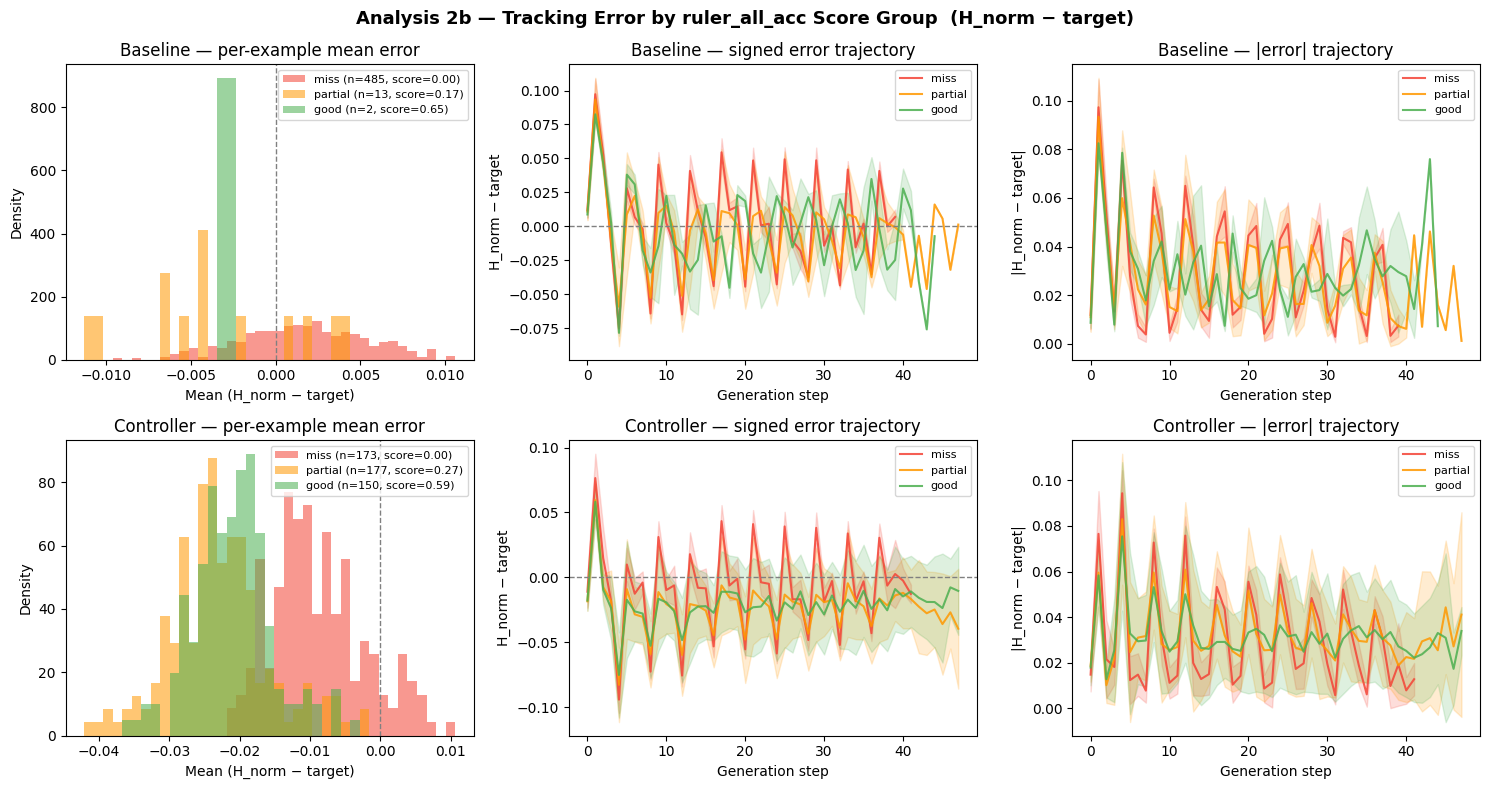

Mean tracking error (H_norm − target) by score group:
                          mean_err    |err|
  Baseline     miss          +0.0017   0.0300
  Baseline     partial       -0.0035   0.0287
  Baseline     good          -0.0031   0.0302
  Controller   miss          -0.0088   0.0303
  Controller   partial       -0.0231   0.0332
  Controller   good          -0.0210   0.0320


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Analysis 2b — Tracking Error by ruler_all_acc Score Group  (H_norm − target)",
             fontsize=13, fontweight="bold")

rows = [
    ("Baseline",   base_err, base_miss_g, base_partial_g, base_good_g, base_score),
    ("Controller", ctrl_err, ctrl_miss_g, ctrl_partial_g, ctrl_good_g, ctrl_score),
]

for row_i, (label, err, miss, partial, good, score) in enumerate(rows):
    sg = [(miss,    "miss",    SG["miss"]),
          (partial, "partial", SG["partial"]),
          (good,    "good",    SG["good"])]

    # col 0: per-example mean error histogram
    ax = axes[row_i, 0]
    all_e = np.concatenate([np.nanmean(err[m], axis=1) for m, _, _ in sg if m.sum()])
    bins  = np.linspace(all_e.min(), all_e.max(), 40)
    for mask, lbl, col in sg:
        if not mask.sum(): continue
        ax.hist(np.nanmean(err[mask], axis=1), bins=bins, alpha=0.55, color=col,
                density=True, label=f"{lbl} (n={mask.sum()}, score={score[mask].mean():.2f})")
    ax.axvline(0, color="gray", ls="--", lw=1)
    ax.set_title(f"{label} — per-example mean error")
    ax.set_xlabel("Mean (H_norm − target)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

    # col 1: signed error trajectory
    ax = axes[row_i, 1]
    for mask, lbl, col in sg:
        if not mask.sum(): continue
        m = np.nanmean(err[mask], axis=0)
        s = np.nanstd(err[mask],  axis=0)
        ax.plot(steps, m, color=col, label=lbl, alpha=0.85)
        ax.fill_between(steps, m-s, m+s, color=col, alpha=BAND)
    ax.axhline(0, color="gray", ls="--", lw=1)
    ax.set_title(f"{label} — signed error trajectory")
    ax.set_xlabel("Generation step")
    ax.set_ylabel("H_norm − target")
    ax.legend(fontsize=8)

    # col 2: |error| trajectory
    ax = axes[row_i, 2]
    for mask, lbl, col in sg:
        if not mask.sum(): continue
        m = np.nanmean(np.abs(err[mask]), axis=0)
        s = np.nanstd(np.abs(err[mask]),  axis=0)
        ax.plot(steps, m, color=col, label=lbl, alpha=0.85)
        ax.fill_between(steps, m-s, m+s, color=col, alpha=BAND)
    ax.set_title(f"{label} — |error| trajectory")
    ax.set_xlabel("Generation step")
    ax.set_ylabel("|H_norm − target|")
    ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

print("Mean tracking error (H_norm − target) by score group:")
print(f"{'':12} {'':10} {'mean_err':>10} {'|err|':>8}")
for label, err, miss, partial, good in [
    ("Baseline",   base_err, base_miss_g, base_partial_g, base_good_g),
    ("Controller", ctrl_err, ctrl_miss_g, ctrl_partial_g, ctrl_good_g),
]:
    for mask, lbl in [(miss, "miss"), (partial, "partial"), (good, "good")]:
        if not mask.sum(): continue
        me  = np.nanmean(err[mask])
        ame = np.nanmean(np.abs(err[mask]))
        print(f"  {label:<12} {lbl:<10} {me:>+10.4f} {ame:>8.4f}")

## Analysis 10 — Matched-example comparison

Groups: **ctrl-only hit** (312), **both hit** (15), **both miss** (173), **base-only hit** (rare).

/tmp/ipykernel_2179293/1745311717.py:25: RuntimeWarning: Mean of empty slice
  m = np.nanmean(H[mask], axis=0)
/tmp/ipykernel_2179293/1745311717.py:48: RuntimeWarning: Mean of empty slice
  ax.plot(steps, np.nanmean(ctrl_Hn[mask] - base_Hn[mask], axis=0),
/tmp/ipykernel_2179293/1745311717.py:69: RuntimeWarning: Mean of empty slice
  m = np.nanmean(ctrl_T[mask], axis=0); s = np.nanstd(ctrl_T[mask], axis=0)
/tmp/ipykernel_2179293/1745311717.py:80: RuntimeWarning: Mean of empty slice
  ax.plot(steps, np.nanmean(ctrl_S[mask], axis=0), color=col,


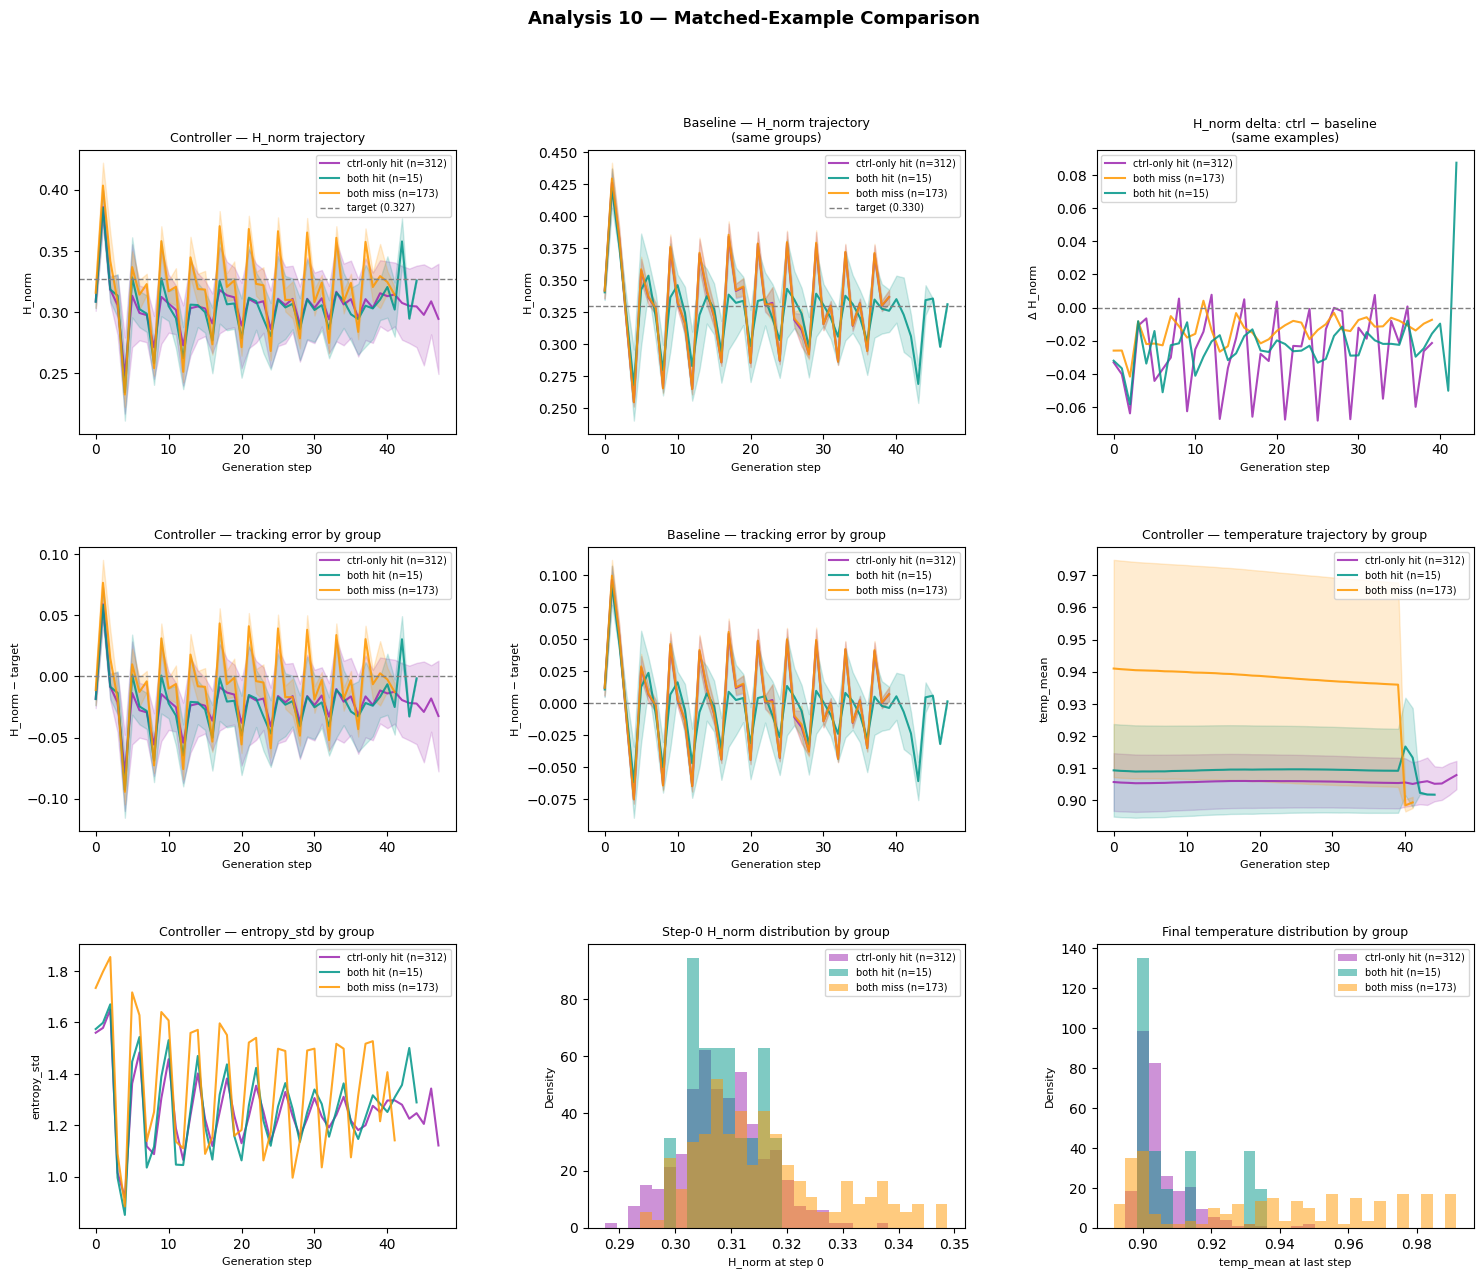

Group summary stats:
group                  n  ctrl_score  base_score   ctrl_Hn   base_Hn   ctrl_err   base_err  ctrl_T_fin
------------------------------------------------------------------------------------------------------
ctrl-only hit        312       41.8%        0.0%    0.3048    0.3314    -0.0220    +0.0015      0.9054
both hit              15       35.3%       23.3%    0.3025    0.3265    -0.0244    -0.0034      0.9092
both miss            173        0.0%        0.0%    0.3180    0.3319    -0.0088    +0.0020      0.9360


In [7]:
GC = {"ctrl_only": "#9C27B0", "both_hit": "#009688", "both_miss": "#FF9800", "base_only": "#2196F3"}
groups = [
    (ctrl_only, "ctrl-only hit", GC["ctrl_only"]),
    (both_hit,  "both hit",      GC["both_hit"]),
    (both_miss, "both miss",     GC["both_miss"]),
    (base_only, "base-only hit", GC["base_only"]),
]

def last_valid(arr):
    out = np.full(arr.shape[0], np.nan)
    for i in range(arr.shape[0]):
        v = np.where(~np.isnan(arr[i]))[0]
        if len(v): out[i] = arr[i, v[-1]]
    return out

ctrl_T_final = last_valid(ctrl_T)

fig = plt.figure(figsize=(18, 14))
fig.suptitle("Analysis 10 — Matched-Example Comparison", fontsize=13, fontweight="bold")
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.35)

def plot_traj(ax, H, tgt, title, ylabel, show_target=False, show_zero=False):
    for mask, lbl, col in groups:
        if not mask.sum(): continue
        m = np.nanmean(H[mask], axis=0)
        s = np.nanstd(H[mask],  axis=0)
        ax.plot(steps, m, color=col, label=f"{lbl} (n={mask.sum()})", alpha=0.85)
        ax.fill_between(steps, m-s, m+s, color=col, alpha=BAND)
    if show_target: ax.axhline(tgt.mean(), color="gray", ls="--", lw=1, label=f"target ({tgt.mean():.3f})")
    if show_zero:   ax.axhline(0, color="gray", ls="--", lw=1)
    ax.set_title(title, fontsize=9); ax.set_xlabel("Generation step", fontsize=8)
    ax.set_ylabel(ylabel, fontsize=8); ax.legend(fontsize=7)

# (0,0) Controller H_norm trajectory vs target
ax = fig.add_subplot(gs[0, 0])
plot_traj(ax, ctrl_Hn, ctrl_tgt, "Controller — H_norm trajectory", "H_norm", show_target=True)

# (0,1) Baseline H_norm trajectory vs target (same groups)
ax = fig.add_subplot(gs[0, 1])
plot_traj(ax, base_Hn, base_tgt, "Baseline — H_norm trajectory\n(same groups)", "H_norm", show_target=True)

# (0,2) H_norm delta: ctrl − baseline
ax = fig.add_subplot(gs[0, 2])
for mask, lbl, col in [(ctrl_only, "ctrl-only hit", GC["ctrl_only"]),
                        (both_miss, "both miss",     GC["both_miss"]),
                        (both_hit,  "both hit",      GC["both_hit"])]:
    if not mask.sum(): continue
    ax.plot(steps, np.nanmean(ctrl_Hn[mask] - base_Hn[mask], axis=0),
            color=col, label=f"{lbl} (n={mask.sum()})", alpha=0.85)
ax.axhline(0, color="gray", ls="--", lw=1)
ax.set_title("H_norm delta: ctrl − baseline\n(same examples)", fontsize=9)
ax.set_xlabel("Generation step", fontsize=8); ax.set_ylabel("Δ H_norm", fontsize=8)
ax.legend(fontsize=7)

# (1,0) Controller normalized tracking error by group
ax = fig.add_subplot(gs[1, 0])
plot_traj(ax, ctrl_err, ctrl_tgt, "Controller — tracking error by group",
          "H_norm − target", show_zero=True)

# (1,1) Baseline normalized tracking error by group
ax = fig.add_subplot(gs[1, 1])
plot_traj(ax, base_err, base_tgt, "Baseline — tracking error by group",
          "H_norm − target", show_zero=True)

# (1,2) Controller temperature trajectory by group
ax = fig.add_subplot(gs[1, 2])
for mask, lbl, col in groups:
    if not mask.sum(): continue
    m = np.nanmean(ctrl_T[mask], axis=0); s = np.nanstd(ctrl_T[mask], axis=0)
    ax.plot(steps, m, color=col, label=f"{lbl} (n={mask.sum()})", alpha=0.85)
    ax.fill_between(steps, m-s, m+s, color=col, alpha=BAND)
ax.set_title("Controller — temperature trajectory by group", fontsize=9)
ax.set_xlabel("Generation step", fontsize=8); ax.set_ylabel("temp_mean", fontsize=8)
ax.legend(fontsize=7)

# (2,0) entropy_std by group
ax = fig.add_subplot(gs[2, 0])
for mask, lbl, col in groups:
    if not mask.sum(): continue
    ax.plot(steps, np.nanmean(ctrl_S[mask], axis=0), color=col,
            label=f"{lbl} (n={mask.sum()})", alpha=0.85)
ax.set_title("Controller — entropy_std by group", fontsize=9)
ax.set_xlabel("Generation step", fontsize=8); ax.set_ylabel("entropy_std", fontsize=8)
ax.legend(fontsize=7)

# (2,1) Step-0 H_norm distribution by group
ax = fig.add_subplot(gs[2, 1])
all_s0 = np.concatenate([ctrl_Hn[m, 0] for m, _, _ in groups if m.sum()])
bins = np.linspace(np.nanmin(all_s0), np.nanmax(all_s0), 30)
for mask, lbl, col in groups:
    if not mask.sum(): continue
    ax.hist(ctrl_Hn[mask, 0], bins=bins, alpha=0.5, color=col, density=True,
            label=f"{lbl} (n={mask.sum()})")
ax.set_title("Step-0 H_norm distribution by group", fontsize=9)
ax.set_xlabel("H_norm at step 0", fontsize=8); ax.set_ylabel("Density", fontsize=8)
ax.legend(fontsize=7)

# (2,2) Final temperature distribution by group
ax = fig.add_subplot(gs[2, 2])
all_ft = np.concatenate([ctrl_T_final[m] for m, _, _ in groups if m.sum()])
bins = np.linspace(np.nanmin(all_ft), np.nanmax(all_ft), 30)
for mask, lbl, col in groups:
    if not mask.sum(): continue
    ax.hist(ctrl_T_final[mask], bins=bins, alpha=0.5, color=col, density=True,
            label=f"{lbl} (n={mask.sum()})")
ax.set_title("Final temperature distribution by group", fontsize=9)
ax.set_xlabel("temp_mean at last step", fontsize=8); ax.set_ylabel("Density", fontsize=8)
ax.legend(fontsize=7)

plt.show()

# Summary table
print("Group summary stats:")
hdr = f"{'group':<18} {'n':>5} {'ctrl_score':>11} {'base_score':>11} {'ctrl_Hn':>9} {'base_Hn':>9} {'ctrl_err':>10} {'base_err':>10} {'ctrl_T_fin':>11}"
print(hdr); print("-"*len(hdr))
for mask, lbl, col in groups:
    if not mask.sum(): continue
    print(f"{lbl:<18} {mask.sum():>5} "
          f"{ctrl_score[mask].mean()*100:>10.1f}% {base_score[mask].mean()*100:>10.1f}% "
          f"{np.nanmean(ctrl_Hn[mask]):>9.4f} {np.nanmean(base_Hn[mask]):>9.4f} "
          f"{np.nanmean(ctrl_err[mask]):>+10.4f} {np.nanmean(base_err[mask]):>+10.4f} "
          f"{np.nanmean(ctrl_T_final[mask]):>11.4f}")